In [ ]:
import random
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
!pip install snntorch
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 5.9 MB/s eta 0:00:00


In [ ]:
batch_size = 64
num_epochs = 200 # Increased epochs (SNNs learn slower)
learning_rate = 2e-3 # Slightly higher LR for SNNs
beta = 0.95 # Decay rate (High beta = "Memory" of previous time steps)
time_steps = 100 #  window size
num_inputs = 32 #  32 EEG channels
num_hidden = 128 # Hidden layer size
num_outputs = 2 # 2 Classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

TIME_DATA_PATH = "/content/Troi_epochs_stride_0.126s_time.npy"
EVENTS_PATH = "/content/Troi_epochs_stride_0.126s_events.npy"


# ==========================================
# 2. DATA LOADING
# ==========================================
# Seed
torch.manual_seed(0)
random.seed(0)
np.random.seed(0)
print(np.load(EVENTS_PATH).shape)

# Reshape data toprint("--- Loading and Preparing Data ---")
time_data = np.load(TIME_DATA_PATH)
events = np.load(EVENTS_PATH)
labels = events[:, 2] #(N, T, C) - Samples, Timesteps, Channels
X = time_data.transpose(0, 2, 1)
y = labels

thumb_vs_other_indices = np.where((y == 1) | (y == 4))[0]
X = X[thumb_vs_other_indices]
y = y[thumb_vs_other_indices]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = [str(c) for c in label_encoder.classes_]

# Split data into training and validation sets first
X_train, X_val, y_train, y_val = train_test_split(
 X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standardize the data
# The scaler needs 2D data, so we reshape: (N, T, C) -> (N*T, C)
n_samples_train, n_timesteps, n_features = X_train.shape
n_samples_val = X_val.shape[0]

X_train_reshaped = X_train.reshape(-1, n_features)
X_val_reshaped = X_val.reshape(-1, n_features)

# Fit the scaler ONLY on the training data to prevent data leakage
scaler = StandardScaler()
scaler.fit(X_train_reshaped)

# Apply the scaler to both train and validation data
X_train_scaled = scaler.transform(X_train_reshaped)
X_val_scaled = scaler.transform(X_val_reshaped)

# Reshape the data back to the (N, T, C) format
X_train = X_train_scaled.reshape(n_samples_train, n_timesteps, n_features)
X_val = X_val_scaled.reshape(n_samples_val, n_timesteps, n_features)

print("Data has been standardized.")

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Create DataLoaders

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

print("Original labels kept:", np.unique(y))
print("Encoded labels:", np.unique(y_encoded))
print("Number of classes:", len(np.unique(y_encoded)))
print("Label mapping:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))



Running on: cuda
(24327, 3)
Data has been standardized.
Original labels kept: [1 4]
Encoded labels: [0 1]
Number of classes: 2
Label mapping: {np.int32(1): 0, np.int32(4): 1}


--- Starting Training ---
DEBUG: spk_rec shape: torch.Size([100, 64, 2])
DEBUG: targets shape: torch.Size([64])
--> New Best Model Saved! (Acc: 49.54%)
--> New Best Model Saved! (Acc: 50.04%)
--> New Best Model Saved! (Acc: 50.34%)
--> New Best Model Saved! (Acc: 50.30%)
--> New Best Model Saved! (Acc: 50.93%)
Epoch 5 | Loss: 104.78 | Val Acc: 50.93% | Train Acc: 51.52%
--> New Best Model Saved! (Acc: 50.55%)
--> New Best Model Saved! (Acc: 50.93%)
--> New Best Model Saved! (Acc: 52.79%)
--> New Best Model Saved! (Acc: 53.34%)
--> New Best Model Saved! (Acc: 55.70%)
Epoch 10 | Loss: 103.73 | Val Acc: 55.70% | Train Acc: 54.96%
--> New Best Model Saved! (Acc: 54.22%)
--> New Best Model Saved! (Acc: 55.28%)
--> New Best Model Saved! (Acc: 57.14%)
--> New Best Model Saved! (Acc: 55.15%)
--> New Best Model Saved! (Acc: 56.67%)
Epoch 15 | Loss: 101.26 | Val Acc: 56.67% | Train Acc: 57.01%
--> New Best Model Saved! (Acc: 60.94%)
--> New Best Model Saved! (Acc: 60.85%)
--> New Best Model Save

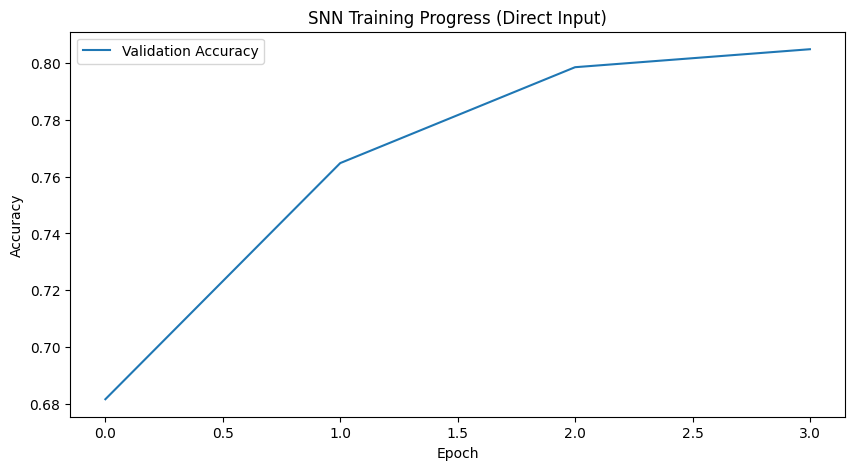

In [7]:
import torch
import torch.nn as nn
class SpikingTransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        # Attention Projections
        self.q_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.k_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.v_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        # Spiking Neuron for Attention Map
        self.attn_lif = snn.Leaky(
            beta=0.9,
            spike_grad=surrogate.fast_sigmoid(slope=5),
            init_hidden=True,
            learn_beta=True,
            learn_threshold=True
        )

        # Feed Forward Part (Reasoning step)
        self.ff_1 = nn.Linear(embed_dim, embed_dim * 2)
        self.ff_lif = snn.Leaky(
            beta=0.9,
            spike_grad=surrogate.fast_sigmoid(slope=5),
            init_hidden=True,
            learn_beta=True,
            learn_threshold=True
        )
        self.ff_2 = nn.Linear(embed_dim * 2, embed_dim)

        # Normalization & Dropout
        self.bn1 = nn.BatchNorm1d(embed_dim)
        self.bn2 = nn.BatchNorm1d(embed_dim)
        self.drop = nn.Dropout(0.3)

    def forward(self, x):
        # x: [Batch, Time, Embed_Dim]
        B, T, C = x.shape

        # --- SUB-BLOCK 1: Attention ---
        residual = x

        q = self.q_proj(x).reshape(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).reshape(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).reshape(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled Dot Product
        attn = (q @ k.transpose(-2, -1)) * self.scale

        # Spiking Softmax
        attn_flat = attn.reshape(B * self.num_heads, T * T)
        self.attn_lif.init_leaky()
        attn_spikes = self.attn_lif(attn_flat)
        attn_spikes = attn_spikes.reshape(B, self.num_heads, T, T)

        # Apply & Project
        out = (attn_spikes @ v).transpose(1, 2).reshape(B, T, C)
        out = self.out_proj(out)
        out = self.drop(out)

        # Add Residual + BatchNorm
        out = out.permute(0, 2, 1)
        out = self.bn1(out)
        out = out.permute(0, 2, 1)

        x = residual + out

        # --- SUB-BLOCK 2: Feed Forward ---
        residual = x

        out = self.ff_1(x)
        self.ff_lif.init_leaky()
        out = self.ff_lif(out)
        out = self.ff_2(out)
        out = self.drop(out)

        # Add Residual + BatchNorm
        out = out.permute(0, 2, 1)
        out = self.bn2(out)
        out = out.permute(0, 2, 1)

        return residual + out

# ==========================================
# 2. THE SCALED ARCHITECTURE: DEEP ST-PLIF
# ==========================================
class Deep_ST_PLIF(nn.Module):
    def __init__(self):
        super().__init__()
        spike_grad = surrogate.fast_sigmoid(slope=5)

        # CONFIGURATION
        self.embed_dim = 256  # Increased from 128
        self.depth = 2        # Increased from 1 (Stacking layers)

        # BLOCK 1: SPLIT POLARITY SPATIAL ENCODER
        # Using Conv1d to mix the 64 split-channels spatially first
        self.spatial_encoder = nn.Conv1d(64, self.embed_dim, kernel_size=1)
        self.bn_in = nn.BatchNorm1d(self.embed_dim)
        self.lif_in = snn.Leaky(
            beta=0.9,
            spike_grad=spike_grad,
            init_hidden=True,
            learn_beta=True,
            learn_threshold=True
        )
        self.drop_in = nn.Dropout(0.3)

        # BLOCK 2: STACKED TRANSFORMER BLOCKS
        self.layers = nn.ModuleList([
            SpikingTransformerBlock(self.embed_dim, num_heads=4)
            for _ in range(self.depth)
        ])

        # BLOCK 3: OUTPUT DECODER
        self.fc_out = nn.Linear(self.embed_dim, 2)
        self.lif_out = snn.Leaky(
            beta=0.9,
            spike_grad=spike_grad,
            init_hidden=True,
            output=True,
            learn_beta=True,
            learn_threshold=True
        )

    def forward(self, x):
        # x: [Batch, Time, 32]

        # 1. SPLIT POLARITY
        pos = torch.relu(x)
        neg = torch.relu(-x)
        x_split = torch.cat([pos, neg], dim=2)  # [Batch, Time, 64]

        # 2. SPATIAL ENCODE
        # Permute for Conv1d: [Batch, 64, Time]
        x_spatial = x_split.permute(0, 2, 1)
        x_spatial = self.spatial_encoder(x_spatial)  # [Batch, 256, Time]
        x_spatial = self.bn_in(x_spatial)

        # Permute back: [Batch, Time, 256]
        x_spatial = x_spatial.permute(0, 2, 1)

        # Initial Spike Generation
        self.lif_in.init_leaky()

        # Loop over time for stateful LIF
        encoded_list = []
        for step in range(x_spatial.size(1)):
            spk = self.lif_in(x_spatial[:, step, :])
            encoded_list.append(spk)

        x_seq = torch.stack(encoded_list, dim=1)  # [Batch, Time, 256]
        x_seq = self.drop_in(x_seq)

        # 3. DEEP TRANSFORMER LOOP
        for layer in self.layers:
            x_seq = layer(x_seq)

        # 4. DECODE / CLASSIFY
        self.lif_out.init_leaky()
        out_spikes = []

        for step in range(x_seq.size(1)):
            cur = self.fc_out(x_seq[:, step, :])
            spk, _ = self.lif_out(cur)
            out_spikes.append(spk)

        return torch.stack(out_spikes, dim=0)  # [Time, Batch, 4]
# ==========================================
# OPTIMIZER
# ==========================================
model = Deep_ST_PLIF().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=2)
history = {'loss': [], 'acc': []}
loss_fn = SF.ce_rate_loss()

print("--- Starting Training ---")
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    train_correct = 0
    train_total = 0
    best_val_acc = 0.0
    for i, (data, targets) in enumerate(train_loader):
        data = data.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        # --- MIXUP IMPLEMENTATION ---
        if torch.rand(1).item() < 0.5:  # Apply MixUp 50% of the time
            lam = np.random.beta(0.5, 0.5)
            index = torch.randperm(data.size(0)).to(device)

            mixed_data = lam * data + (1 - lam) * data[index]

            # Forward pass with mixed data
            spk_rec = model(mixed_data)  # [Time, Batch, 4]

            # MixUp loss
            loss = (
                lam * loss_fn(spk_rec, targets)
                + (1 - lam) * loss_fn(spk_rec, targets[index])
            )
        else:
            # Normal forward pass
            spk_rec = model(data)  # [Time, Batch, 4]
            loss = loss_fn(spk_rec, targets)

        # --- DEBUG CHECK (first batch of first epoch only) ---
        if epoch == 0 and i == 0:
            print(f"DEBUG: spk_rec shape: {spk_rec.shape}")
            print(f"DEBUG: targets shape: {targets.shape}")

        # Backward pass
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Training accuracy
        acc = SF.accuracy_rate(spk_rec, targets)
        train_correct += acc * targets.size(0)
        train_total += targets.size(0)

    scheduler.step()

    # ---------- Validation ----------
    model.eval()
    val_total = 0
    val_correct = 0

    with torch.no_grad():
        for data, targets in val_loader:
            data = data.to(device)
            targets = targets.to(device)

            spk_rec = model(data)
            acc = SF.accuracy_rate(spk_rec, targets)

            val_correct += acc * targets.size(0)
            val_total += targets.size(0)

    val_acc = val_correct / val_total
    train_acc = train_correct / train_total


    # Inside the loop, after validation
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model_checkpoint.pth")
        print(f"--> New Best Model Saved! (Acc: {best_val_acc*100:.2f}%)")

    # Also save "latest" every 50 epochs just in case
    if (epoch + 1) % 50 == 0:
        torch.save(model.state_dict(), f"checkpoint_epoch_{epoch+1}.pth")
        history["loss"].append(epoch_loss)
        history["acc"].append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1} | "
            f"Loss: {epoch_loss:.2f} | "
            f"Val Acc: {val_acc*100:.2f}% | "
            f"Train Acc: {train_acc*100:.2f}%"
        )

PATH = "450_epoch_SNN_transformer.pth"
torch.save(model.state_dict(),PATH)
# ==========================================
# 5. FINAL PLOT
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(history['acc'], label="Validation Accuracy")
plt.title("SNN Training Progress (Direct Input)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
